# MSCS-634 Lab 6: Association Rule Mining
**Name:** Pranoj Thapa  
**Course:** Advanced Big Data and Data Mining  
**Lab:** Association Rule Mining using Apriori and FP-Growth

In [1]:
!pip install mlxtend seaborn pandas matplotlib

In [2]:
import pandas as pd

# Simple transaction dataset
dataset = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Diapers', 'Beer', 'Eggs'],
    ['Milk', 'Bread', 'Diapers', 'Beer'],
    ['Bread', 'Milk', 'Diapers', 'Beer'],
    ['Milk', 'Bread', 'Butter'],
]

df = pd.DataFrame(dataset)
df

,0,1,2,3
0,Milk,Bread,Butter,None
1,Bread,Diapers,Beer,Eggs
2,Milk,Bread,Diapers,Beer
3,Bread,Milk,Diapers,Beer
4,Milk,Bread,Butter,None


In [3]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(dataset).transform(dataset)

df = pd.DataFrame(te_data, columns=te.columns_)
df

,Beer,Bread,Butter,Diapers,Eggs,Milk
0,False,True,True,False,False,True
1,True,True,False,True,True,False
2,True,True,False,True,False,True
3,True,True,False,True,False,True
4,False,True,True,False,False,True


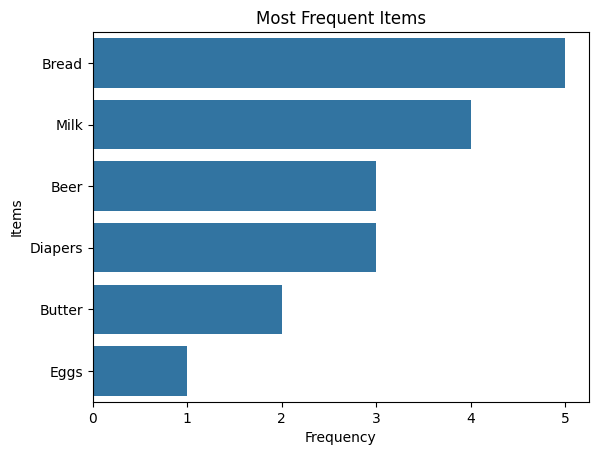

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count frequency of items
item_counts = df.sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=item_counts.values, y=item_counts.index)
plt.title("Most Frequent Items")
plt.xlabel("Frequency")
plt.ylabel("Items")
plt.show()

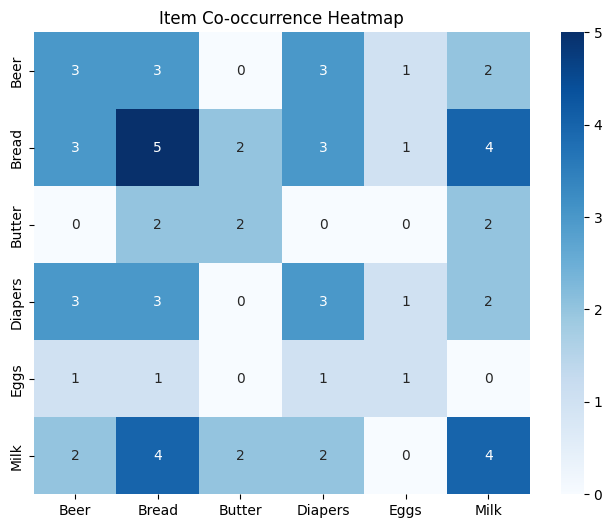

In [5]:
# Item co-occurrence matrix
co_occurrence = df.astype(int).T.dot(df.astype(int))

plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, annot=True, cmap="Blues", fmt="d")
plt.title("Item Co-occurrence Heatmap")
plt.show()

In [6]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets_apriori = apriori(df, min_support=0.4, use_colnames=True)
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values(by="support", ascending=False)

frequent_itemsets_apriori

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
1,1.0,(Bread)
10,0.8,"(Milk, Bread)"
4,0.8,(Milk)
6,0.6,"(Beer, Diapers)"
0,0.6,(Beer)
5,0.6,"(Beer, Bread)"
3,0.6,(Diapers)
13,0.6,"(Beer, Bread, Diapers)"
9,0.6,"(Bread, Diapers)"
2,0.4,(Butter)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

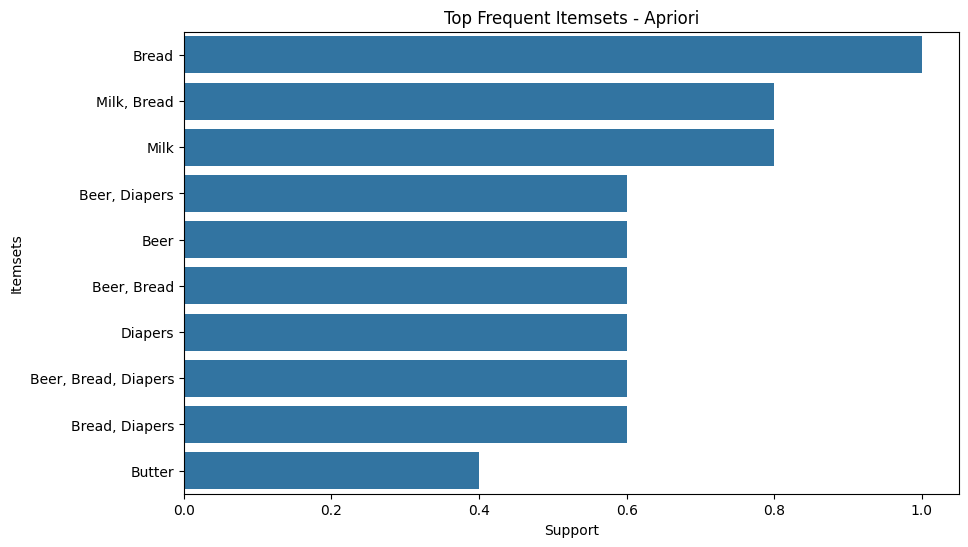

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
apriori_plot = frequent_itemsets_apriori.copy()
apriori_plot["itemsets"] = apriori_plot["itemsets"].apply(lambda x: ', '.join(list(x)))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=apriori_plot.head(10), x="support", y="itemsets")
plt.title("Top Frequent Itemsets - Apriori")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

In [8]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets_fp = fpgrowth(df, min_support=0.4, use_colnames=True)
frequent_itemsets_fp = frequent_itemsets_fp.sort_values(by="support", ascending=False)

frequent_itemsets_fp

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,1.0,(Bread)
1,0.8,(Milk)
5,0.8,"(Milk, Bread)"
13,0.6,"(Beer, Bread)"
3,0.6,(Diapers)
4,0.6,(Beer)
9,0.6,"(Bread, Diapers)"
12,0.6,"(Beer, Diapers)"
15,0.6,"(Beer, Bread, Diapers)"
2,0.4,(Butter)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

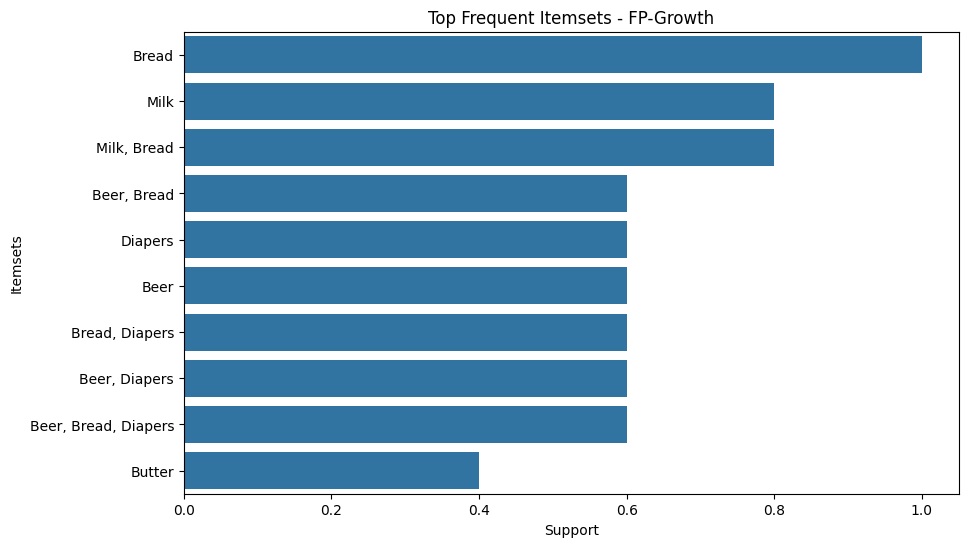

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
fp_plot = frequent_itemsets_fp.copy()
fp_plot["itemsets"] = fp_plot["itemsets"].apply(lambda x: ', '.join(list(x)))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=fp_plot.head(10), x="support", y="itemsets")
plt.title("Top Frequent Itemsets - FP-Growth")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

In [10]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth

start = time.time()
apriori(df, min_support=0.4, use_colnames=True)
apriori_time = time.time() - start

start = time.time()
fpgrowth(df, min_support=0.4, use_colnames=True)
fp_time = time.time() - start

print("Apriori Runtime:", apriori_time)
print("FP-Growth Runtime:", fp_time)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Apriori Runtime: 0.020399808883666992
FP-Growth Runtime: 0.015306234359741211


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
from mlxtend.frequent_patterns import association_rules

rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.6)
rules_apriori = rules_apriori.sort_values(by="lift", ascending=False)

rules_apriori

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(Beer),(Diapers),0.6,0.6,0.6,1.000000,1.666667,1.0,0.24,inf,1.000000,1.000000,1.000000,1.000000
6,"(Beer, Bread)",(Diapers),0.6,0.6,0.6,1.000000,1.666667,1.0,0.24,inf,1.000000,1.000000,1.000000,1.000000
3,(Diapers),(Beer),0.6,0.6,0.6,1.000000,1.666667,1.0,0.24,inf,1.000000,1.000000,1.000000,1.000000
9,(Beer),"(Bread, Diapers)",0.6,0.6,0.6,1.000000,1.666667,1.0,0.24,inf,1.000000,1.000000,1.000000,1.000000
8,"(Bread, Diapers)",(Beer),0.6,0.6,0.6,1.000000,1.666667,1.0,0.24,inf,1.000000,1.000000,1.000000,1.000000
40,"(Bread, Diapers)","(Beer, Milk)",0.6,0.4,0.4,0.666667,1.666667,1.0,0.16,1.8,1.000000,0.666667,0.444444,0.833333
23,"(Milk, Diapers)",(Beer),0.4,0.6,0.4,1.000000,1.666667,1.0,0.16,inf,0.666667,0.666667,1.000000,0.833333
21,"(Beer, Milk)",(Diapers),0.4,0.6,0.4,1.000000,1.666667,1.0,0.16,inf,0.666667,0.666667,1.000000,0.833333
25,(Diapers),"(Beer, Milk)",0.6,0.4,0.4,0.666667,1.666667,1.0,0.16,1.8,1.000000,0.666667,0.444444,0.833333
24,(Beer),"(Milk, Diapers)",0.6,0.4,0.4,0.666667,1.666667,1.0,0.16,1.8,1.000000,0.666667,0.444444,0.833333


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

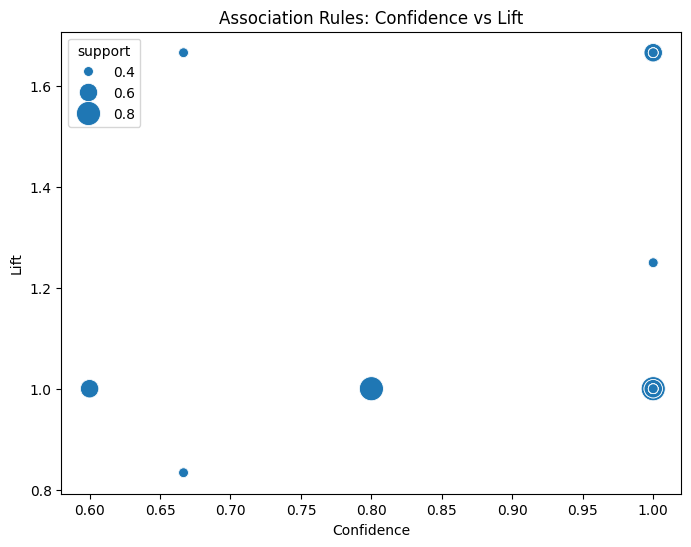

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rules_apriori,
    x="confidence",
    y="lift",
    size="support",
    sizes=(50, 300)
)
plt.title("Association Rules: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()

## Comparative Analysis

In this lab, both Apriori and FP-Growth were used to mine frequent itemsets from the transactional dataset. Both algorithms produced similar frequent itemsets because they used the same minimum support threshold. However, FP-Growth was faster than Apriori. This is because Apriori generates many candidate itemsets and checks them repeatedly, while FP-Growth uses a compressed tree structure to mine patterns more efficiently.

One challenge in this lab was converting the transactional data into the one-hot encoded format required by the algorithms. This was solved using the TransactionEncoder class from mlxtend. Another challenge was understanding how to interpret support, confidence, and lift. Support shows how often an itemset appears, confidence shows the likelihood that one item is purchased when another item is purchased, and lift shows the strength of the relationship compared to random chance.

The results showed that Bread and Milk appeared frequently together, indicating a meaningful association. The visualizations helped make the frequent itemsets and rules easier to interpret.

## Key Insights

The analysis showed that Bread was the most frequent item in the dataset. Milk and Bread appeared together in multiple transactions, indicating a strong association between these items. Association rules with high confidence and lift suggest that the purchase of one item can help predict the purchase of another.

These patterns are useful in real-world applications such as market basket analysis, product placement, and recommendation systems. Businesses can use these insights to improve sales strategies and customer experience.